# Task 5: High school grades in Oslo
- Group: 36
- Candidate number: 4, 49, 63, 82

For this task we explore high school grade statistics from Oslo, using
publicly available data from Udir. The goal is to get a feel for what the
data looks like, find patterns worth highlighting, and finally use the
data to investigate a more focused question.

We use two separate CSV files in this task:

- The first file, used in **5.1** and **5.2**, covers grades for Oslo high
  schools in 2024-25. It breaks the data down across several dimensions:
  assessment type (standpunkt, skriftlig, muntlig), ownership (offentlig
  and privat schools), and gender. This gives us enough flexibility to
  look at the data from different angles during exploration.
- The second file, used in **5.3**, is loaded specifically to answer the
  problem we define there. We introduce it together with the problem in
  that section.

Task 5 is divided into three parts:

- **5.1** – Getting the data and loading it in
- **5.2** – Exploring the data with visualisations
- **5.3** – Defining a specific problem and implementing a Python solution

## 5.1 - Loading the data

### Source

The data for this analysis is publicly available from Udir's (the Norwegian
Directorate for Education and Training) grade statistics portal:
https://www.udir.no/tall-og-forskning/statistikk/statistikk-videregaende-skole/karakterer-vgs/

### Filter choices on Udir's portal

Udir lets you narrow the data before downloading. Our choices were:

- **Region**: Oslo high schools, set through the Enhet (unit/entity) filter
- **School year**: 2024-25, the most recent year currently published
- **Assessment types**: standpunkt (teacher's final grade), skriftlig
  (written exam) and muntlig (oral exam). Keeping all three is essential
  since the comparison between them is what we want to study
- **Ownership and gender**: we kept the breakdowns by school ownership
  (offentlig (public) and privat (private)) and by student gender
  (gutt (boy) and jente (girl)), so we can compare these dimensions in 5.2
- **Subjects**: a curated subset of the curriculum rather than everything
  available

### Choosing subjects

There wasn't a strict rule behind which subjects we kept. What we ended up
with is a fairly representative slice of what studieforberedende (general
studies, college-preparatory) students sit through during their three
years: Norsk (Norwegian) in all its variants, Matematikk 2P (Mathematics
2P, a practical-oriented math course), Historie (History), Naturfag
(Natural Sciences), Samfunnskunnskap (Social Studies), Kroppsøving
(Physical Education), and Tysk II (German II) as a foreign-language
representative. Ten subjects altogether.

Looking back at it, the mix happens to work well for what we want to do.
We've got subjects that end in a written exam (Matematikk, Norsk hovedmål
(main written form of Norwegian) / sidemål (secondary written form)
skriftlig, Tysk II), subjects that end in an oral exam (Historie, Norsk
muntlig, Samfunnskunnskap, Naturfag), and even Kroppsøving where there's
no exam at all, just standpunkt. That spread is genuinely useful for the
analysis. We just want to be honest that it wasn't designed that way from
the start.

### File handling

Udir's CSV is exported in UTF-16 LE with tab separators and Norwegian-style
comma decimals, a giveaway that it has been through an Excel pipeline at
some point. Once pandas is told about the encoding and separator, the rest
is straightforward.

The file contains 64 columns covering grades across multiple dimensions
(assessment type, ownership, gender). We load 11 grade columns plus 3
metadata columns, chosen to support the analysis:

- **Muntlig** (oral exam): only the aggregated value (all ownership types,
  all genders)
- **Skriftlig** (written exam) and **standpunkt** (teacher's final grade):
  aggregated value plus separate columns for gender (gutt/jente) and
  ownership (offentlig/privat)

This gives us enough flexibility to compare ownership types and the gender
gap for the two assessment types we focus on, while keeping the loading
simple for muntlig which isn't the main focus.

Grade strings are converted to floats by replacing the Norwegian decimal
comma with a period. Suppressed values (marked with `*` in the source
file) are converted to `NaN`.

In [51]:
import pandas as pd

# List of columns we want to include
columns = [
    'EnhetNivaa',
    'EnhetNavn',
    'Vurderingsfagnavn',
    # Muntlig (oral) - only aggregate
    '2024-25.Muntlig eksamen.Alle eierformer.Alle kjønn.Snittkarakter',
    # Skriftlig (written) - aggregate + gender + ownership splits
    '2024-25.Skriftlig eksamen.Alle eierformer.Alle kjønn.Snittkarakter',
    '2024-25.Skriftlig eksamen.Alle eierformer.Gutt.Snittkarakter',
    '2024-25.Skriftlig eksamen.Alle eierformer.Jente.Snittkarakter',
    '2024-25.Skriftlig eksamen.Offentlig skole.Alle kjønn.Snittkarakter',
    '2024-25.Skriftlig eksamen.Privat eiet.Alle kjønn.Snittkarakter',
    # Standpunkt (teachers final grade) - aggregate + gender + ownership splits
    '2024-25.Standpunkt.Alle eierformer.Alle kjønn.Snittkarakter',
    '2024-25.Standpunkt.Alle eierformer.Gutt.Snittkarakter',
    '2024-25.Standpunkt.Alle eierformer.Jente.Snittkarakter',
    '2024-25.Standpunkt.Offentlig skole.Alle kjønn.Snittkarakter',
    '2024-25.Standpunkt.Privat eiet.Alle kjønn.Snittkarakter',
]

# Load the CSV with correct encoding and separator
df = pd.read_csv(
    'csvFiles/dataOslo2024-2025.csv',
    encoding='utf-16-le',
    sep='\t',
    skiprows=1,
    usecols=columns
)

# Rename columns to shorter, readable names
df = df.rename(columns={
    'EnhetNavn': 'skole',
    'Vurderingsfagnavn': 'fag',
    # Muntlig
    '2024-25.Muntlig eksamen.Alle eierformer.Alle kjønn.Snittkarakter': 'muntlig',
    # Skriftlig - all variants
    '2024-25.Skriftlig eksamen.Alle eierformer.Alle kjønn.Snittkarakter': 'skriftlig',
    '2024-25.Skriftlig eksamen.Alle eierformer.Gutt.Snittkarakter': 'skriftlig_gutt',
    '2024-25.Skriftlig eksamen.Alle eierformer.Jente.Snittkarakter': 'skriftlig_jente',
    '2024-25.Skriftlig eksamen.Offentlig skole.Alle kjønn.Snittkarakter': 'skriftlig_offentlig',
    '2024-25.Skriftlig eksamen.Privat eiet.Alle kjønn.Snittkarakter': 'skriftlig_privat',
    # Standpunkt - all variants
    '2024-25.Standpunkt.Alle eierformer.Alle kjønn.Snittkarakter': 'standpunkt',
    '2024-25.Standpunkt.Alle eierformer.Gutt.Snittkarakter': 'standpunkt_gutt',
    '2024-25.Standpunkt.Alle eierformer.Jente.Snittkarakter': 'standpunkt_jente',
    '2024-25.Standpunkt.Offentlig skole.Alle kjønn.Snittkarakter': 'standpunkt_offentlig',
    '2024-25.Standpunkt.Privat eiet.Alle kjønn.Snittkarakter': 'standpunkt_privat',
})

# Basic types
df['EnhetNivaa'] = df['EnhetNivaa'].astype(int)
df['skole'] = df['skole'].astype(str)
df['fag'] = df['fag'].astype(str)

# Convert grade columns: Norwegian comma to float, '*' becomes NaN
def convert_grade(value):
    #Convert '4,2' to 4.2, and '*' or other non-numeric values to NaN.
    if pd.isna(value):
        return float('nan')
    if isinstance(value, str):
        value = value.replace(',', '.')
        try:
            return float(value)
        except ValueError:
            return float('nan')   # handles '*' (suppressed values)
    return float(value)

# Apply conversion to all grade columns
grade_columns = [
    'muntlig',
    'skriftlig', 'skriftlig_gutt', 'skriftlig_jente',
    'skriftlig_offentlig', 'skriftlig_privat',
    'standpunkt', 'standpunkt_gutt', 'standpunkt_jente',
    'standpunkt_offentlig', 'standpunkt_privat',
]

for col in grade_columns:
    df[col] = df[col].apply(convert_grade)

In [52]:
# Verify the loaded data
print(f"Shape: {df.shape}")
print(f"Number of unique subjects: {df['fag'].nunique()}")
print(f"Number of unique schools: {df[df['EnhetNivaa'] == 3]['skole'].nunique()}")

print(f"\nDatatypes:")
print(df.dtypes)

print(f"\nGrade column statistics (should be between 1.0 and 6.0):")
print(df[['muntlig', 'skriftlig', 'standpunkt']].describe().round(2))

print(f"\nMissing values per column:")
print(df.isna().sum())

print(f"\nSample of rows with grade data:")
df.dropna(subset=['muntlig', 'skriftlig', 'standpunkt'], how='all').sample(5, random_state=42)

Shape: (324, 14)
Number of unique subjects: 10
Number of unique schools: 36

Datatypes:
EnhetNivaa                int64
fag                         str
skole                       str
muntlig                 float64
skriftlig               float64
skriftlig_gutt          float64
skriftlig_jente         float64
skriftlig_offentlig     float64
skriftlig_privat        float64
standpunkt              float64
standpunkt_gutt         float64
standpunkt_jente        float64
standpunkt_offentlig    float64
standpunkt_privat       float64
dtype: object

Grade column statistics (should be between 1.0 and 6.0):
       muntlig  skriftlig  standpunkt
count   108.00     108.00      294.00
mean      4.54       3.50        4.29
std       0.58       0.68        0.65
min       2.90       1.60        2.40
25%       4.30       3.08        3.82
50%       4.60       3.55        4.30
75%       4.90       3.92        4.80
max       5.60       5.10        6.00

Missing values per column:
EnhetNivaa            

,EnhetNivaa,fag,skole,muntlig,skriftlig,skriftlig_gutt,skriftlig_jente,skriftlig_offentlig,skriftlig_privat,standpunkt,standpunkt_gutt,standpunkt_jente,standpunkt_offentlig,standpunkt_privat
194,3,"Norsk hovedmål, vg3 studieforberedende utdanni...",Foss videregående skole,NaN,4.1,3.9,4.2,4.1,NaN,4.4,4.2,4.5,4.4,NaN
166,3,Naturfag vg1 studieforberedende utdanningsprogram,Kongsskogen videregående skole,NaN,NaN,NaN,NaN,NaN,NaN,5.3,NaN,NaN,5.3,NaN
123,3,Matematikk 2P,Eikelund videregående skole,NaN,NaN,NaN,NaN,NaN,NaN,3.1,NaN,NaN,3.1,NaN
215,3,"Norsk hovedmål, vg3 studieforberedende utdanni...",Vika videregående skole,NaN,3.7,3.7,3.7,3.7,NaN,4.2,4.2,4.3,4.2,NaN
70,3,Historie Vg3 studieforberedende utdanningsprogram,Otto Treider private gymnas AS,3.8,NaN,NaN,NaN,NaN,NaN,4.5,4.0,4.8,NaN,4.5


The verification tells us the load went as planned. We've got 324 rows across
14 columns, all grade columns are stored as floats, and missing values land
as `NaN` like we wanted. The high NaN count in the `_privat` and `_offentlig`
columns might look alarming at first, but it actually makes sense — each row
represents a single school, so it can only be either public or private, not
both. The "wrong" column ends up as `NaN`.

### An important observation about the dataset structure

When we first explored the data, we noticed that no single row contains
grades for all three assessment types at the same time. This isn't a data
problem. It reflects how the Norwegian school system actually works: each
subject only carries the assessment types that apply to it.

A few examples illustrate the pattern:

- **Matematikk 2P** has standpunkt and a written exam, but no oral
- **Historie Vg3** has standpunkt and an oral exam, but no written
- **Kroppsøving Vg3** has only standpunkt, since PE has no exam at all
- **Norsk** is split into three separate entries: hovedmål skriftlig,
  sidemål skriftlig, and muntlig

This has a practical consequence for the analysis. We cannot take a single
row and compare standpunkt against both exam types side by side. Instead,
we need to use **pairwise comparisons**, grouping subjects by the exam
type they actually have:

- Standpunkt vs **written exams**: Matematikk 2P, Norsk skriftlig (hovedmål
  and sidemål), and Tysk II
- Standpunkt vs **oral exams**: Historie, Norsk muntlig, Naturfag, and
  Samfunnskunnskap

With this structure understood, the analysis can proceed correctly.

## Visualisation 1 - Written Exam Grades: Norwegian Main vs Secondary Language

This bar chart compares the average written exam grades in Norwegian main language (hovedmål)
and secondary language (sidemål) for Oslo high schools in 2024-25, split by school type.

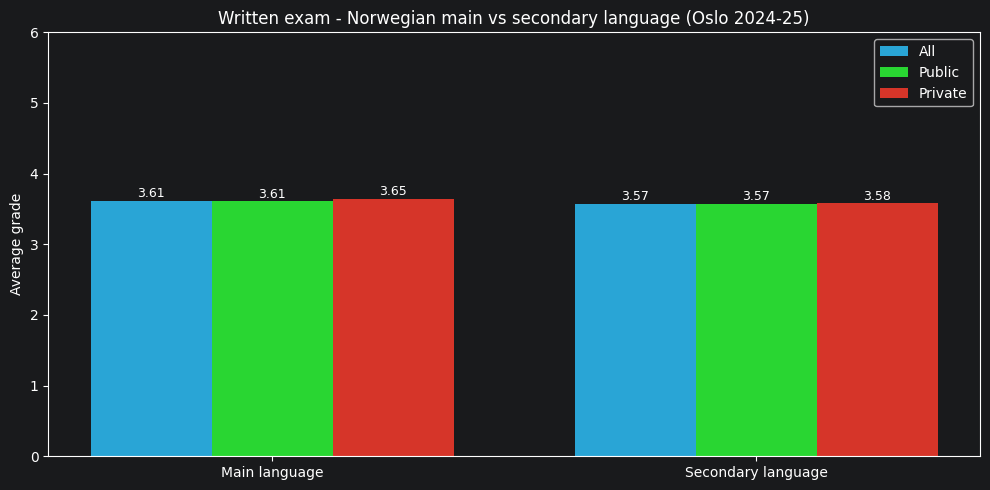

In [53]:
import matplotlib.pyplot as plt

norwegian = df[df['fag'].isin([
    'Norsk hovedmål, vg3 studieforberedende utdanningsprogram, skriftlig',
    'Norsk sidemål, vg3 studieforberedende utdanningsprogram, skriftlig'
])]

# Calculate average per subject
avg_all = norwegian.groupby('fag')['skriftlig'].mean()
avg_public = norwegian.groupby('fag')['skriftlig_offentlig'].mean()
avg_private = norwegian.groupby('fag')['skriftlig_privat'].mean()

labels = ['Main language', 'Secondary language']
x = range(len(labels))
width = 0.25

plt.figure(figsize=(10, 5))

# Store the bar containers so we can add labels to them
bars_all = plt.bar([i - width for i in x], avg_all.values, width, label='All', color='#29a5d6')
bars_public = plt.bar([i for i in x], avg_public.values, width, label='Public', color='#29d632')
bars_private = plt.bar([i + width for i in x], avg_private.values, width, label='Private', color='#d63529')

# Add value labels on top of each bar
for bars in [bars_all, bars_public, bars_private]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
        bar.get_x() + bar.get_width() / 2,   # x-position: center of the bar
        height + 0.05,  # y-position: just above the bar
        f'{height:.2f}',    # text: 2 decimal places
        ha='center',    # horizontal alignment: center
            fontsize=9
        )

plt.xticks(list(x), labels)
plt.ylabel('Average grade')
plt.title('Written exam - Norwegian main vs secondary language (Oslo 2024-25)')
plt.ylim(0, 6)
plt.legend()
plt.tight_layout()
plt.show()

### A note on the matplotlib methods we used

Most of the plotting code follows patterns directly from Lecture 11 (Data
Visualisation, Matplotlib and Seaborn). The bulk of what we use comes
straight from the lecture examples: `plt.figure(figsize=...)`, `plt.bar(...)`,
`plt.xticks(...)`, `plt.xlabel(...)`, `plt.ylabel(...)`, `plt.title(...)`,
`plt.legend()`, `plt.tight_layout()`, and `plt.show()`.

We did add a couple of extras to make the plot easier to read, and we want
to be open about that:

- **`plt.ylim(0, 6)`** locks the y-axis to the Norwegian grade scale (1 to 6)
  so the bar charts in this section share the same scale. This makes it
  fair to compare bars across subjects, since otherwise matplotlib would
  auto-scale each plot differently.
- **`plt.text()`** places the average value directly above each bar. We
  added this because some of the bars end up close in height, and reading
  the exact numbers from the y-axis alone gets tricky.

To position the text correctly we use `bar.get_x()`, `bar.get_height()`,
and `bar.get_width()`, which come from the bar objects returned by
`plt.bar()`. Together they let us put the value right at the top centre
of each bar.

The chart shows that private schools achieve marginally higher grades than public schools in
both Norwegian main language and secondary language. The difference is small, suggesting that
school type has limited impact on written exam performance in Norwegian for Oslo schools in
2024-25. Overall, grades in main language are slightly higher than secondary language across
all school types.

### Visualisation 2 - Boys vs Girls in Mathematics 2P (standpunkt)

This bar chart zooms in on one specific subject, Matematikk 2P, and compares
the average standpunkt grade given to boys against the one given to girls
across Oslo high schools in 2024-25.

The picture is clear: girls come out slightly higher than boys on average.
The gap is small but consistent, which lines up with the broader pattern
we've seen elsewhere in Norwegian school statistics where girls tend to
edge ahead of boys in most academic subjects.


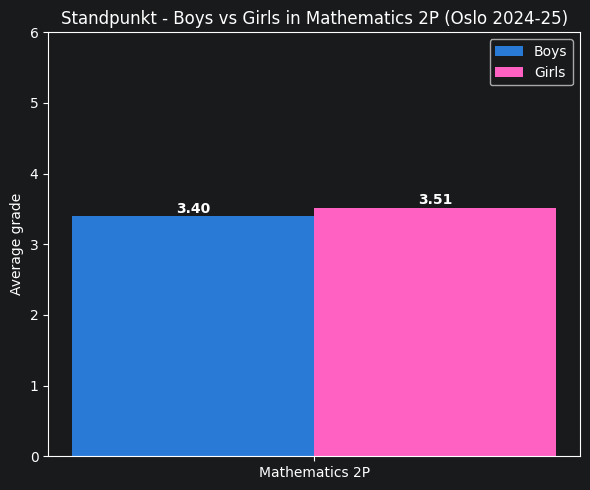

In [54]:
import matplotlib.pyplot as plt

#Filter the dataset to only Matematikk 2P
math = df[df['fag'] == 'Matematikk 2P']

# Calculates the average standpunkt grade for boys and girls separately
avg_boys = math['standpunkt_gutt'].mean()
avg_girls = math['standpunkt_jente'].mean()

width = 0.35

# Draw two bars side by side, one for each gender
fig, ax = plt.subplots(figsize=(6, 5))
bars_boys = ax.bar(0 - width/2, avg_boys, width, label='Boys', color='#297ad6')
bars_girls = ax.bar(0 + width/2, avg_girls, width, label='Girls', color='#ff61c2')

# Add value labels on top of each bar
for bars in [bars_boys, bars_girls]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.05,
            f'{height:.2f}',
            ha='center',
            fontsize=10,
            fontweight='bold'
        )

# Final styling: labels, title, y-range and legend
ax.set_xticks([0])
ax.set_xticklabels(['Mathematics 2P'])
ax.set_ylabel('Average grade')
ax.set_title('Standpunkt - Boys vs Girls in Mathematics 2P (Oslo 2024-25)')
ax.set_ylim(0, 6)
ax.legend()
plt.tight_layout()
plt.show()

### Visualisation 3 - Boys vs Girls across all subjects (standpunkt)

After zooming in on Matematikk 2P in the previous visualisation, this line chart
broadens the view to see whether the gender gap holds across all the subjects
we have in the dataset. Each point represents the average standpunkt grade
per subject for Oslo high schools in 2024-25, with boys on one line and
girls on the other.

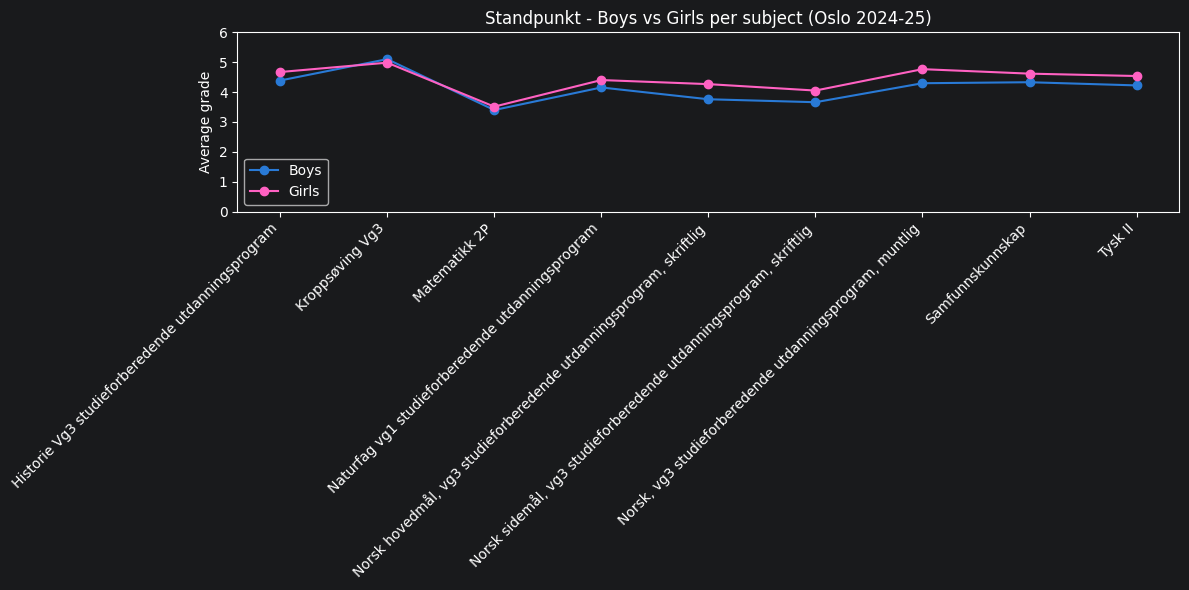

In [55]:
import matplotlib.pyplot as plt

# Calculates the average standpunkt grade for boys and girls, grouped per subject
gender_avg = df.groupby('fag')[['standpunkt_gutt', 'standpunkt_jente']].mean()

# Builds the line chart with one line per gender across all subjects
plt.figure(figsize=(12, 6))
plt.plot(gender_avg.index, gender_avg['standpunkt_gutt'], marker='o', label='Boys', color='#297ad6')
plt.plot(gender_avg.index, gender_avg['standpunkt_jente'], marker='o', label='Girls', color='#ff61c2')

# Final styling: labels, title, y-range and legend
plt.xticks(rotation=45, ha='right')
plt.ylabel('Average grade')
plt.title('Standpunkt - Boys vs Girls per subject (Oslo 2024-25)')
plt.ylim(0, 6)
plt.legend()
plt.tight_layout()
plt.show()

The general pattern is consistent: girls sit above boys on most subjects,
sometimes by a noticeable margin. The gap is widest in **Norsk hovedmål**
and **Norsk muntlig**, where girls clearly come out ahead. There's one
interesting exception worth flagging: **Kroppsøving Vg3**, where boys
actually score slightly higher than girls. PE seems to follow its own
logic, possibly because the grading is more tied to physical performance
than to the kind of academic engagement that drives the gap in other
subjects.

Taken together with Visualisation 2, this confirms that the small gender
gap we saw in Matematikk 2P isn't an isolated case. It's part of a
broader pattern across the Norwegian curriculum.

### Visualisation 4 - Average grade across all assessment types

This bar chart steps back from individual subjects and looks at the bigger
picture: what's the average grade across all subjects, broken down by
assessment type? We compute one average per type (standpunkt, skriftlig
eksamen, and muntlig eksamen) so we can compare them side by side.

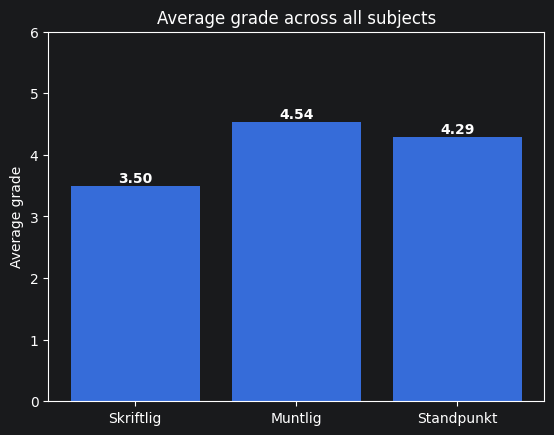

In [56]:
# Select only the three grade columns from the dataset
avg_grades = df[["skriftlig", "muntlig", "standpunkt"]]

# Calculates the overall average for each assessment type
avg_written = avg_grades["skriftlig"].mean()
avg_muntlig = avg_grades["muntlig"].mean()
avg_standpunkt = avg_grades["standpunkt"].mean()

# Set up the labels and values for the bar chart
avg_labels = ['Skriftlig', 'Muntlig', 'Standpunkt']
avg_values = [avg_written, avg_muntlig, avg_standpunkt]

# Draws the bar chart with one bar per assessment type
bars = plt.bar(avg_labels, avg_values)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.05,
        f'{height:.2f}',
        ha='center',
        fontsize=10,
        fontweight='bold',
        color='#fff'
    )

# Final styling: labels, title and y-range
plt.ylabel('Average grade')
plt.title("Average grade across all subjects")

plt.ylim(0, 6)
plt.show()

Muntlig eksamen sits at the top at 4.54 on average, standpunkt follows
closely at 4.29, and skriftlig eksamen lands noticeably lower at 3.50.
That's a gap of just over one full grade point between muntlig and
skriftlig. In other words, the oral exam tends to be the most generous
of the three, the teacher's standpunkt sits in the middle, and the
written exam pulls grades down the most.

### Visualisation 5 – Which Oslo schools stand out the most?

After looking at variation within subjects in Visualisation 4, this final
chart flips the perspective one more time and asks the question from the
other side: how do the schools themselves compare? For each Oslo school in
the dataset, we calculate the average standpunkt grade across all subjects
it offers (requiring at least three subjects, so a school with only one or
two entries doesn't skew the picture), then plot the top 10 and the bottom
10 side by side.

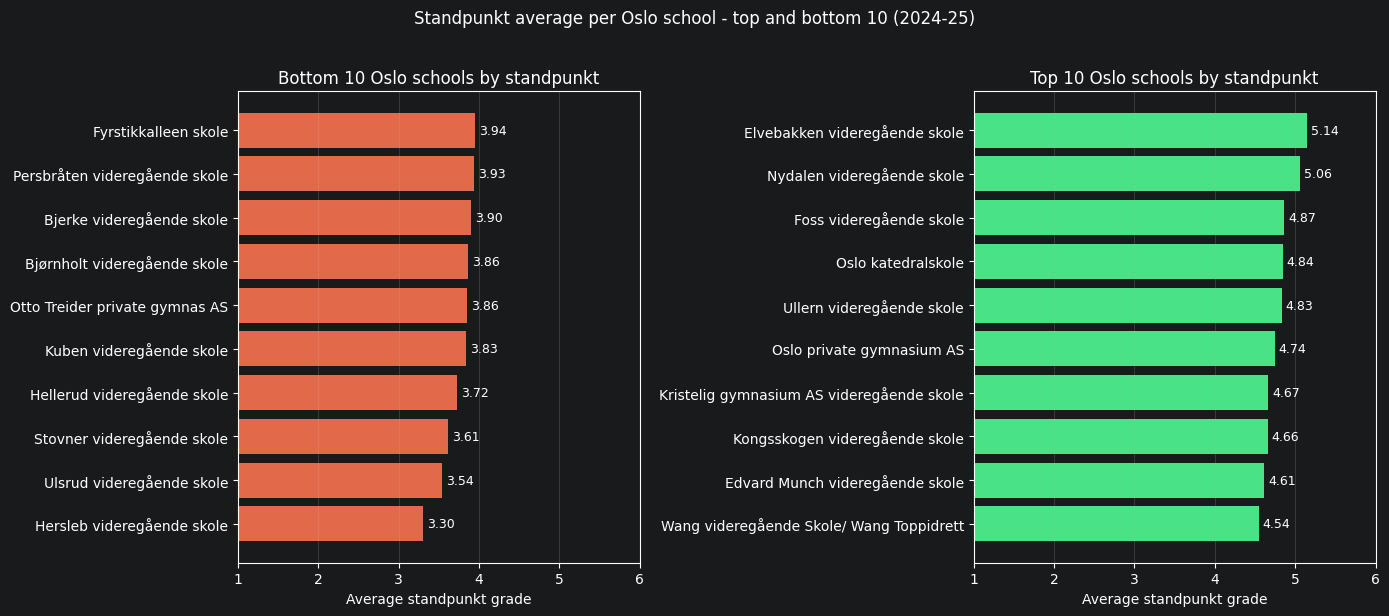

In [57]:
import matplotlib.pyplot as plt

# Only school-level rows
schools = df[df['EnhetNivaa'] == 3]

# Average standpunkt per school (across all subjects they offer)
school_avg = schools.groupby('skole')['standpunkt'].mean().sort_values()

# Filter to schools with enough data (at least 3 subjects)
school_counts = schools.groupby('skole')['standpunkt'].count()
valid_schools = school_counts[school_counts >= 3].index
school_avg = school_avg[school_avg.index.isin(valid_schools)]

# Top 10 and bottom 10
top_10 = school_avg.tail(10)
bottom_10 = school_avg.head(10)

# Plot side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Bottom 10
bars_bottom = ax1.barh(bottom_10.index, bottom_10.values, color='#e26a4a')
ax1.set_xlim(1, 6)
ax1.set_xlabel('Average standpunkt grade')
ax1.set_title('Bottom 10 Oslo schools by standpunkt')
ax1.grid(axis='x', alpha=0.3)
for bar in bars_bottom:
    width = bar.get_width()
    ax1.text(width + 0.05, bar.get_y() + bar.get_height()/2,
             f'{width:.2f}', va='center', fontsize=9)

# Top 10
bars_top = ax2.barh(top_10.index, top_10.values, color='#4ae287')
ax2.set_xlim(1, 6)
ax2.set_xlabel('Average standpunkt grade')
ax2.set_title('Top 10 Oslo schools by standpunkt')
ax2.grid(axis='x', alpha=0.3)

# Adds the grade value next to each top 10 bar
for bar in bars_top:
    width = bar.get_width()
    ax2.text(width + 0.05, bar.get_y() + bar.get_height()/2,
             f'{width:.2f}', va='center', fontsize=9)

# Final styling: shared title above both subplots
plt.suptitle('Standpunkt average per Oslo school - top and bottom 10 (2024-25)', y=1.02)
plt.tight_layout()
plt.show()

The highest-ranked school sits at 5.14 on average (Elvebakken vgs), while
the lowest-ranked one lands at 3.30 (Hersleb vgs). That's a gap of almost
two full grade points based purely on which school a student happens to
attend. In a system that uses a 1-6 scale, that's a substantial difference.

That said, we want to be careful about reading too much into this ranking.
A school landing high or low here doesn't necessarily mean teaching quality
explains everything. A few factors can pull the numbers in either direction:

- **Student intake**: some schools attract academically stronger students
  through admission criteria, reputation, or geography
- **Subject mix**: a school heavy on theoretical subjects may naturally
  land at a different average than one focused on practical programs
- **Sample size**: smaller schools with fewer subjects in the dataset are
  more vulnerable to random variation year to year

Keeping these factors in mind, the ranking is more useful as a starting
point for asking deeper questions than as a definitive scoreboard. It's
exactly the kind of pattern that motivates the focused analysis in 5.3,
where we move from describing what the data looks like to actually testing
the Aftenposten hypothesis.

## Summary of findings

Five visualisations later, we have a clearer picture of the Oslo 2024-25
grade data.

- **Ownership type** (public vs private) makes a small difference at most.
  Private schools edge slightly ahead in Norwegian written exams, but not
  by much (Visualisation 1).
- **Gender** makes a more visible difference. Girls outperform boys across
  almost all subjects in standpunkt, with Norsk leading the gap.
  Kroppsøving Vg3 is the one clean exception, where boys score higher
  (Visualisations 2 and 3).
- **Schools themselves** vary the most. There's significant spread within
  subjects, and the top 10 Oslo schools sit roughly 1.5 grade points
  above the bottom 10 (Visualisations 4 and 5).


## 5.3 - Standpunkt vs. exam grades in Norwegian high schools

### Problem definition

There has been ongoing public debate about systematic gaps between standpunkt
grades and exam grades in Norwegian high schools. Udir's own statistics indicate
that written exam grades tend to be lower than standpunkt grades, while oral exam
grades tend to be higher. Aftenposten has covered this pattern in detail, comparing
standpunkt and exam grades across all Norwegian high schools. (Aftenposten, 2023)

We define the problem as follows: do Norwegian high schools show the same
standpunkt vs. exam grade pattern described in public debate, and has it been
consistent across the years where comparable data exists (2022-25)? To avoid
drawing conclusions based on a single region, we compare two counties, Oslo
and Rogaland, which also lets us check whether the pattern varies by geography.
We use Norsk hovedmål as a case subject since it includes all three assessment
forms, making it well suited for this kind of comparison.

References:
Aftenposten. (2013, February 15). *Se om skolen din er streng eller snill med karakterene*. https://www.aftenposten.no/norge/i/3j7pM/se-om-skolen-din-er-streng-eller-snill-med-karakterene
### Data

To answer this we load grade data for Oslo and Rogaland covering the period
2022-25. The starting point is 2022 rather than earlier years because a new
national curriculum (Fagfornyelsen) was introduced in 2022, which changed both
subject codes and assessment forms. Records from before 2022 belong to the old
curriculum, and those subject codes contain no exam grades at all - only
standpunkt. Including them would risk comparing grades awarded under different
frameworks, so we focused on the years where complete data exists.

Both counties were downloaded as a single CSV file from Udir, using the same
filter settings for school year, subject and assessment type.

In [58]:
import pandas as pd

columns = [
    'EnhetNivaa',
    'EnhetNavn',
    'Fylke',
    'Vurderingsfagkode',
    'Vurderingsfagnavn',
    '2022-23.Muntlig eksamen.Alle eierformer.Alle kjønn.Snittkarakter',
    '2022-23.Skriftlig eksamen.Alle eierformer.Alle kjønn.Snittkarakter',
    '2022-23.Standpunkt.Alle eierformer.Alle kjønn.Snittkarakter',
    '2023-24.Muntlig eksamen.Alle eierformer.Alle kjønn.Snittkarakter',
    '2023-24.Skriftlig eksamen.Alle eierformer.Alle kjønn.Snittkarakter',
    '2023-24.Standpunkt.Alle eierformer.Alle kjønn.Snittkarakter',
    '2024-25.Muntlig eksamen.Alle eierformer.Alle kjønn.Snittkarakter',
    '2024-25.Skriftlig eksamen.Alle eierformer.Alle kjønn.Snittkarakter',
    '2024-25.Standpunkt.Alle eierformer.Alle kjønn.Snittkarakter',
]

df = pd.read_csv('csvFiles/dataOsloRogNorsk2022-2025.csv',
                 encoding='utf-16-le',
                 sep='\t',
                 skiprows=1,
                 usecols=columns)

df = df.rename(columns={
    '2022-23.Muntlig eksamen.Alle eierformer.Alle kjønn.Snittkarakter': 'Muntlig_2022-23',
    '2022-23.Skriftlig eksamen.Alle eierformer.Alle kjønn.Snittkarakter': 'Skriftlig_2022-23',
    '2022-23.Standpunkt.Alle eierformer.Alle kjønn.Snittkarakter': 'Standpunkt_2022-23',
    '2023-24.Muntlig eksamen.Alle eierformer.Alle kjønn.Snittkarakter': 'Muntlig_2023-24',
    '2023-24.Skriftlig eksamen.Alle eierformer.Alle kjønn.Snittkarakter': 'Skriftlig_2023-24',
    '2023-24.Standpunkt.Alle eierformer.Alle kjønn.Snittkarakter': 'Standpunkt_2023-24',
    '2024-25.Muntlig eksamen.Alle eierformer.Alle kjønn.Snittkarakter': 'Muntlig_2024-25',
    '2024-25.Skriftlig eksamen.Alle eierformer.Alle kjønn.Snittkarakter': 'Skriftlig_2024-25',
    '2024-25.Standpunkt.Alle eierformer.Alle kjønn.Snittkarakter': 'Standpunkt_2024-25',
})

# EnhetNivaa 3 corresponds to individual schools. We filter out county-level
df = df[df['EnhetNivaa'] == 3]

# EnhetNivaa is no longer needed since all remaining rows are school-level
dr = df.drop(columns=['EnhetNivaa'])

# Shorten the subject names for cleaner labels in plots and tables
df['Vurderingsfagnavn'] = df['Vurderingsfagnavn'].replace({
    'Norsk hovedmål, vg3 studieforberedende utdanningsprogram, skriftlig': 'Norsk hovedmål skriftlig',
    'Norsk, vg3 studieforberedende utdanningsprogram, muntlig': 'Norsk muntlig',
})

# Grade values use Norwegian decimal commas - replace with periods before
# converting to float. Values marked with '*' (suppressed for small groups)
for col in ['Muntlig_2022-23', 'Skriftlig_2022-23', 'Standpunkt_2022-23',
            'Muntlig_2023-24', 'Skriftlig_2023-24', 'Standpunkt_2023-24',
            'Muntlig_2024-25', 'Skriftlig_2024-25', 'Standpunkt_2024-25']:
    df[col] = pd.to_numeric(df[col].str.replace(',', '.'), errors='coerce')

for year in ['2022-23', '2023-24', '2024-25']:
    print(f"\n=== {year} ===")
    print(df[['EnhetNavn', f'Standpunkt_{year}', f'Skriftlig_{year}']]
          .to_string(index=False, float_format='{:.2f}'.format))


=== 2022-23 ===
                                                EnhetNavn  Standpunkt_2022-23  Skriftlig_2022-23
                                        Akademiet Oslo AS                4.00               4.30
                                 Akademiet Vgs Bislett AS                4.00               4.60
                                Bjerke videregående skole                4.00               4.70
                             Bjørnholt videregående skole                2.80               3.40
                              Blindern videregående skole                4.20               3.80
Den Tysk-Norske skolen i Oslo avd grunnskole Sporveisgata                4.20                NaN
                          Edvard Munch videregående skole                4.20               4.90
                              Eikelund videregående skole                4.10                NaN
                            Elvebakken videregående skole                4.70               4.40
             

### Comparing standpunkt and written exam grades

To measure the gap between standpunkt and written exam grades, we filter the
dataset to subject code NOR1267 (Norsk hovedmål skriftlig) and calculate the
difference for each school year. A positive difference means standpunkt is higher
than the written exam grade, which is the pattern described in public debate.



In [59]:
# Filter to written exam subject using its Udir subject code
df_written = df[df['Vurderingsfagkode'] == 'NOR1267'].copy()

# Calculating diffrance
df_written['Diff_2022-23'] = df_written['Standpunkt_2022-23'] - df_written['Skriftlig_2022-23']
df_written['Diff_2023-24'] = df_written['Standpunkt_2023-24'] - df_written['Skriftlig_2023-24']
df_written['Diff_2024-25'] = df_written['Standpunkt_2024-25'] - df_written['Skriftlig_2024-25']


print("Written exam vs standpunkt per year: ")
print(df_written[['EnhetNavn', 'Diff_2022-23', 'Diff_2023-24', 'Diff_2024-25']]
      .to_string(index=False, float_format='{:.2f}'.format))

Written exam vs standpunkt per year: 
                                                EnhetNavn  Diff_2022-23  Diff_2023-24  Diff_2024-25
                                        Akademiet Oslo AS         -0.30          0.60          0.80
                                 Akademiet Vgs Bislett AS         -0.60          0.60          0.60
                                Bjerke videregående skole         -0.70          0.80          0.70
                             Bjørnholt videregående skole         -0.60          0.50          0.50
                              Blindern videregående skole          0.40          0.40          0.20
Den Tysk-Norske skolen i Oslo avd grunnskole Sporveisgata           NaN          0.10          0.50
                          Edvard Munch videregående skole         -0.70          0.10          0.30
                              Eikelund videregående skole           NaN          0.50          0.90
                            Elvebakken videregående skole     

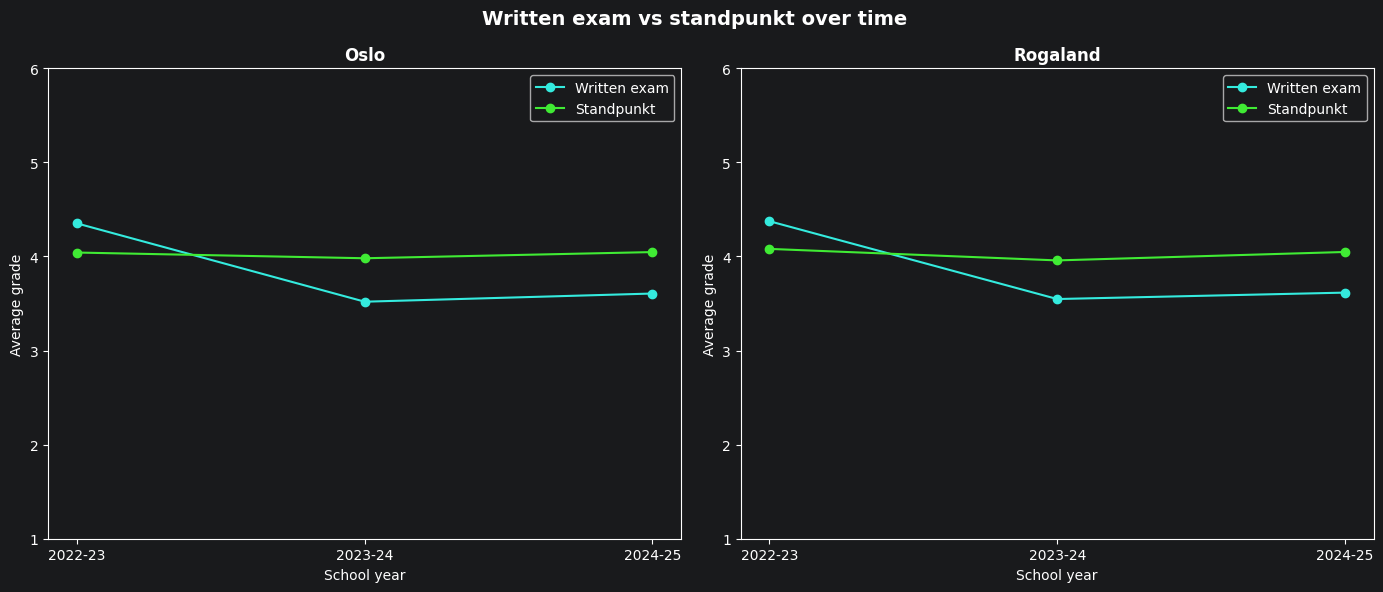

In [60]:
import matplotlib.pyplot as plt

# School years to iterate over
years = ['2022-23', '2023-24', '2024-25']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Written exam vs standpunkt over time', fontsize=14, fontweight='bold')

for idx, county in enumerate(['Oslo', 'Rogaland']):
    # Filter to one county at a time
    df_county = df_written[df_written['Fylke'] == county]

    # Calculate county average for each year and assessment type
    avg_written  = [df_county[f'Skriftlig_{y}'].mean() for y in years]
    avg_standpunkt = [df_county[f'Standpunkt_{y}'].mean() for y in years]

    ax = axes[idx]
    ax.plot(years, avg_written,  marker='o', label='Written exam', color='#34ebde')
    ax.plot(years, avg_standpunkt, marker='o', label='Standpunkt', color='#40eb34')

    ax.set_title(county, fontsize=12, fontweight='bold')
    ax.set_xlabel('School year')
    ax.set_ylabel('Average grade')
    ax.set_ylim(1, 6)
    ax.legend()

plt.tight_layout()
plt.show()

### Comparing standpunkt and oral exam grades

We repeat the same analysis for the oral exam, filtering to subject code NOR1269
(Norsk muntlig). Based on the pattern described in public debate, we expect oral
exam grades to be higher than standpunkt - the opposite direction from the written
exam.

In [61]:
# Filter to oral exam subject using its Udir subject code
df_oral = df[df['Vurderingsfagkode'] == 'NOR1269'].copy()

# Calculating diffrance
df_oral['Diff_2022-23'] = df_oral['Standpunkt_2022-23'] - df_oral['Muntlig_2022-23']
df_oral['Diff_2023-24'] = df_oral['Standpunkt_2023-24'] - df_oral['Muntlig_2023-24']
df_oral['Diff_2024-25'] = df_oral['Standpunkt_2024-25'] - df_oral['Muntlig_2024-25']


print("Oral exam vs standpunkt per year: ")
for year in ['2022-23', '2023-24', '2024-25']:
    print(f"\n=== {year} ===")
    subset = df_oral[['EnhetNavn', f'Muntlig_{year}', f'Standpunkt_{year}', f'Diff_{year}']].dropna()
    print(subset.to_string(index=False, float_format='{:.2f}'.format))

Oral exam vs standpunkt per year: 

=== 2022-23 ===
                                EnhetNavn  Muntlig_2022-23  Standpunkt_2022-23  Diff_2022-23
                        Akademiet Oslo AS             4.30                4.20         -0.10
                 Akademiet Vgs Bislett AS             4.40                4.70          0.30
                Bjerke videregående skole             4.20                4.60          0.40
             Bjørnholt videregående skole             3.60                3.50         -0.10
              Blindern videregående skole             4.60                4.70          0.10
          Edvard Munch videregående skole             4.70                4.60         -0.10
            Elvebakken videregående skole             5.30                5.30          0.00
                  Foss videregående skole             5.30                5.10         -0.20
                     Fyrstikkalleen skole             4.30                4.60          0.30
                  

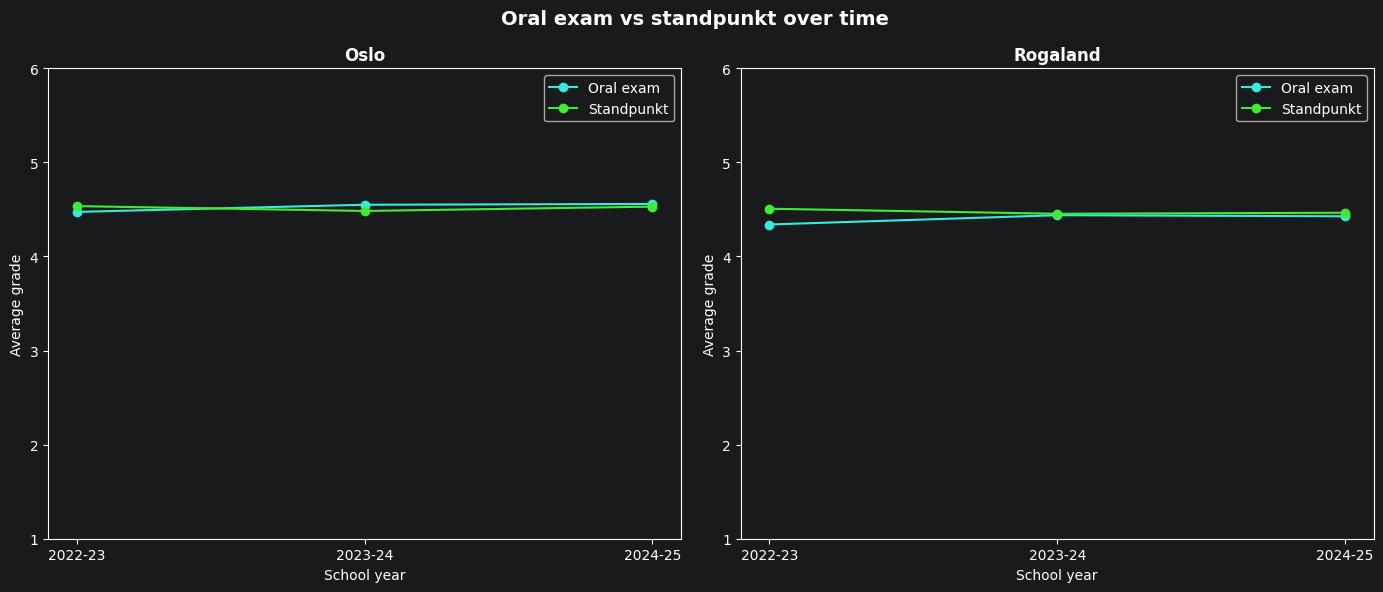

In [62]:
import matplotlib.pyplot as plt

# School years to iterate over
years = ['2022-23', '2023-24', '2024-25']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Oral exam vs standpunkt over time', fontsize=14, fontweight='bold')

for idx, county in enumerate(['Oslo', 'Rogaland']):
    # Filter to one county at a time
    df_county = df_oral[df_oral['Fylke'] == county]

    # Calculate county average for each year and assessment type
    avg_oral = [df_county[f'Muntlig_{y}'].mean() for y in years]
    avg_standpunkt = [df_county[f'Standpunkt_{y}'].mean() for y in years]

    ax = axes[idx]
    ax.plot(years, avg_oral, marker='o', label='Oral exam', color='#34ebde')
    ax.plot(years, avg_standpunkt, marker='o', label='Standpunkt', color='#40eb34')

    ax.set_title(county, fontsize=12, fontweight='bold')
    ax.set_xlabel('School year')
    ax.set_ylabel('Average grade')
    ax.set_ylim(1, 6)
    ax.legend()

plt.tight_layout()
plt.show()

### Summary of grade gaps by county

To get a cleaner picture of the overall pattern, we calculate the average
standpunkt - exam gap per county across all three school years. This collapses
the school-level data into a single summary table, making it easier to compare
Oslo and Rogaland directly and to see whether the gaps are consistent over time.


In [65]:
print("Written exam - average difference (standpunkt - exam):")
print(df_written.groupby('Fylke')[['Diff_2022-23', 'Diff_2023-24', 'Diff_2024-25']].mean().round(2).to_string())

print("\nOral exam - average difference (standpunkt - exam):")
print(df_oral.groupby('Fylke')[['Diff_2022-23', 'Diff_2023-24', 'Diff_2024-25']].mean().round(2).to_string())

Written exam - average difference (standpunkt - exam):
          Diff_2022-23  Diff_2023-24  Diff_2024-25
Fylke                                             
Oslo             -0.28          0.45          0.44
Rogaland         -0.30          0.40          0.43

Oral exam - average difference (standpunkt - exam):
          Diff_2022-23  Diff_2023-24  Diff_2024-25
Fylke                                             
Oslo              0.08         -0.08         -0.02
Rogaland          0.16          0.06          0.06


### Findings

The results largely confirm the pattern described in public debate, but with one
notable exception in the first year of data.

**Written exam (NOR1267)**

In 2023-24 and 2024-25, standpunkt is consistently higher than the written exam
grade in both counties - with gaps of around 0.4 to 0.45 grade points. This
matches the expected pattern. However, in 2022-23 the relationship is reversed:
standpunkt is actually slightly lower than the written exam in both Oslo (-0.28)
and Rogaland (-0.30). This is the first year under the new curriculum
(Fagfornyelsen), and it is unclear whether this reflects a genuine difference in
grading that year or something specific to the transition between curricula.

**Oral exam (NOR1269)**

The oral exam picture is less clear-cut. In Oslo, standpunkt is slightly higher
than the oral exam in 2022-23, then flips negative in 2023-24 and 2024-25
meaning oral exam grades edge above standpunkt in the later years, which is
consistent with the expected pattern. In Rogaland however, standpunkt remains
slightly above the oral exam across all three years. The differences are small
(below 0.2 grade points) and the two lines in the plot are nearly indistinguishable,
suggesting that for oral exams the gap is much smaller than for written exams and
less consistent across counties.

**Overall**

The standpunkt - written exam gap is the clearest and most consistent signal in
the data, and it aligns with what Udir and Aftenposten have reported at the
national level. The oral exam pattern is weaker and more mixed. Both counties
behave very similarly, which suggests the patterns are not specific to Oslo but
reflect a broader national trend.